# Data Exploration

This is everything I could not figure out how to do in R.

In [4]:
# importing packages
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# setting colors
tb, tr, tg, tp, to = ('tab:blue', 'tab:red', 'tab:green', 'tab:purple', 'tab:orange')

# reading in df_bills.csv
df_bills = pd.read_csv('df_bills.csv')

In [6]:
# masks for desired variables
outcomes = ['stage_1', 'stage_2', 'stage_3', 'stage_4', 'passed']
subjects = ['educ', 'cj_civ', 'econ', 'health', 'other', 'gov_ops', 'env_nr']
one_hots = ['committee1', 'cospon1', 'floorspon1', 'money1', 'chamber1']
misc = ['cospon_num', 'num_sub_new', 'num_sub', 'money_sum_real']
econ = ['unemp_rate', 'real_gdp', 'read_gdp_pct', 'gfund_real']

### Outcomes

In [7]:
# outcomes shapes
print(df_bills[outcomes].describe())

           stage_1      stage_2      stage_3      stage_4       passed
count  6730.000000  6730.000000  6730.000000  6730.000000  6730.000000
mean      0.197325     0.001337     0.006835     0.794502     0.794502
std       0.398010     0.036547     0.082398     0.404095     0.404095
min       0.000000     0.000000     0.000000     0.000000     0.000000
25%       0.000000     0.000000     0.000000     1.000000     1.000000
50%       0.000000     0.000000     0.000000     1.000000     1.000000
75%       0.000000     0.000000     0.000000     1.000000     1.000000
max       1.000000     1.000000     1.000000     1.000000     1.000000


You are most likely to have a bill get to either Stage 1 (die in their originating chamber, 19%) or Stage 4 (pass and be signed into law, 79.5%).

### Subjects

Gov_ops has by far the most amount of bills, probably because this is the subject that the Legisilature has the largest jurisdiction over. The least is env_nr, which I find surprising given it's high pass rate. I think this reflects the strong influence of farming/agriculture and mining over the legislature; they do not want a lot of regulation, and when they do want something, they get it passed quickly. Need to look at mining and agriculture industry specs in Utah. 

Env_nr, econ, and health are the highest pass rate subjects (besides other). However, there is not too much variation in pass rates between subjects. Barely more than half are above the overall passing rate; I doubt that they will be very significant in prediciting passage. The most significant pass rate deviation is education; this surprises me since there has been a recent influx of education bills (mostly higher-ed) in recent sessions.

In [8]:
# subjects
for subj in subjects:
    total_bills = df_bills[subj].value_counts()[1]
    total_pass = df_bills.loc[df_bills['passed']==1, subj].value_counts()[1]
    print(f'\n===={subj}====')
    print(f'Total Bills: {total_bills}')
    print(f'Total Bills Passed: {total_pass}')
    print(f'Percent Bills Passed: {round((total_pass/total_bills)*100, 2)}%')


====educ====
Total Bills: 744
Total Bills Passed: 567
Percent Bills Passed: 76.21%

====cj_civ====
Total Bills: 885
Total Bills Passed: 690
Percent Bills Passed: 77.97%

====econ====
Total Bills: 981
Total Bills Passed: 805
Percent Bills Passed: 82.06%

====health====
Total Bills: 1099
Total Bills Passed: 877
Percent Bills Passed: 79.8%

====other====
Total Bills: 811
Total Bills Passed: 657
Percent Bills Passed: 81.01%

====gov_ops====
Total Bills: 1610
Total Bills Passed: 1254
Percent Bills Passed: 77.89%

====env_nr====
Total Bills: 600
Total Bills Passed: 497
Percent Bills Passed: 82.83%


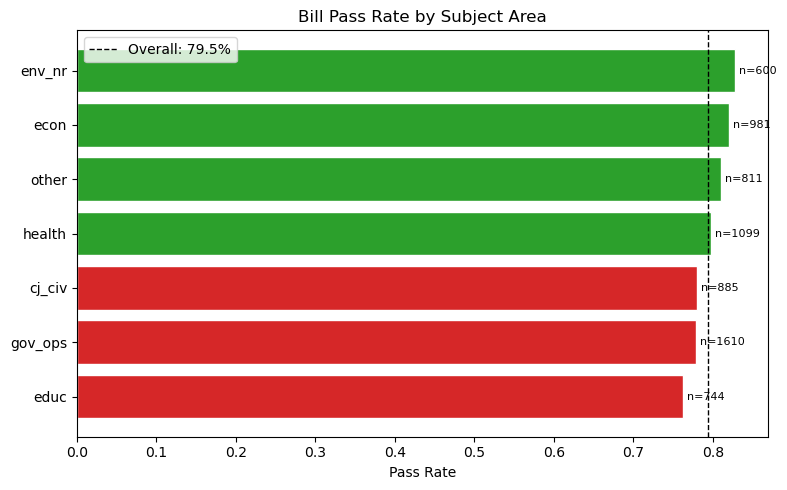

In [10]:
# Calculate pass rate for each subject
pass_rates = {}
for col in subjects:
    subset = df_bills[df_bills[col] == 1]
    if len(subset) > 0:
        pass_rates[col] = {'pass_rate': subset['passed'].mean(), 'count': len(subset)}

pr_df = pd.DataFrame(pass_rates).T.sort_values('pass_rate', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [tg if r > df_bills['passed'].mean() else tr for r in pr_df['pass_rate']]
bars = ax.barh(pr_df.index, pr_df['pass_rate'], color=colors, edgecolor='white')
ax.axvline(df_bills['passed'].mean(), color='black', linestyle='--', linewidth=1, label=f'Overall: {df_bills["passed"].mean():.1%}')
ax.set_xlabel('Pass Rate')
ax.set_title('Bill Pass Rate by Subject Area')
ax.legend()

# Annotate with counts
for bar, (_, row) in zip(bars, pr_df.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={int(row["count"])}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### Binary Coded Variables (cospon1, money1, party1, chamber1, committee1)

**Money Appropriated**: 

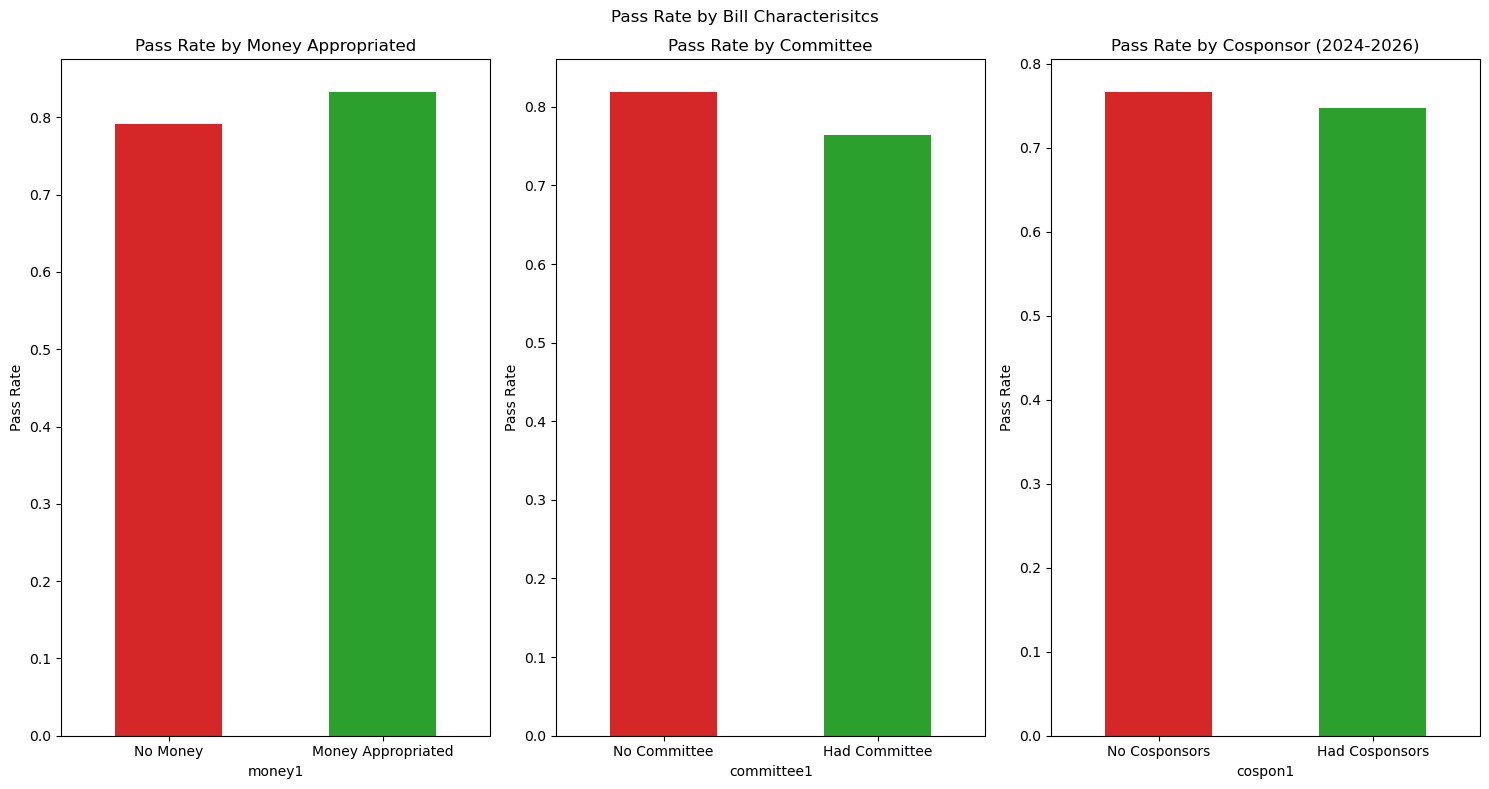

In [36]:
# plotting pass rate for binary variables: cospon1, money1, party1, chamber
fig, axs = plt.subplots(1, 3, figsize=(15,8))

# if it had money appropriated
ax=axs[0]
df_bills.groupby('money1')['passed'].mean().plot(kind='bar', ax=ax, color = [tr, tg])
ax.set_title('Pass Rate by Money Appropriated')
ax.set_xticklabels(['No Money', 'Money Appropriated'], rotation=0)
ax.set_ylabel('Pass Rate')

# if it was ever in a committee
ax=axs[1]
df_bills.groupby('committee1')['passed'].mean().plot(kind='bar', ax=ax, color = [tr, tg])
ax.set_title('Pass Rate by Committee')
ax.set_xticklabels(['No Committee', 'Had Committee'], rotation=0)
ax.set_ylabel('Pass Rate')

# consponsor status
mask = df_bills['session_year'] >= 2023
ax=axs[2]
df_bills[mask].groupby('cospon1')['passed'].mean().plot(kind='bar', ax=ax, color = [tr, tg])
ax.set_title('Pass Rate by Cosponsor (2024-2026)')
ax.set_xticklabels(['No Cosponsors', 'Had Cosponsors'], rotation=0)
ax.set_ylabel('Pass Rate')

plt.suptitle('Pass Rate by Bill Characterisitcs')
plt.tight_layout()
plt.show()

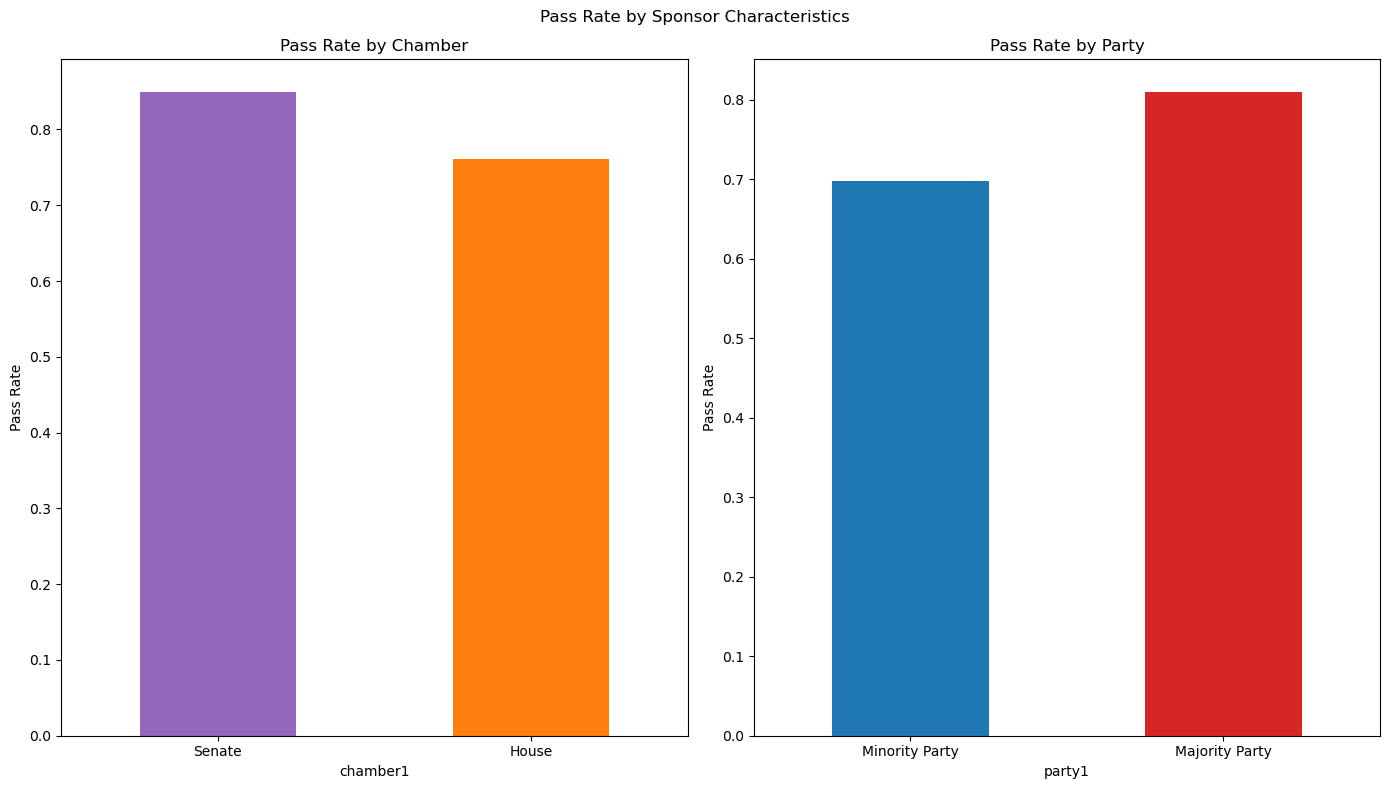

In [33]:
# non-bill-specific characteristics
fig, axs = plt.subplots(1, 2, figsize = (14, 8))

# originating chamber
ax=axs[0]
df_bills.groupby('chamber1')['passed'].mean().plot(kind='bar', ax=ax, color = [tp, to])
ax.set_title('Pass Rate by Chamber')
ax.set_xticklabels(['Senate', 'House'], rotation=0)
ax.set_ylabel('Pass Rate')


# party
ax=axs[1]
df_bills.groupby('party1')['passed'].mean().plot(kind='bar', ax=ax, color = [tb, tr])
ax.set_title('Pass Rate by Party')
ax.set_xticklabels(['Minority Party', 'Majority Party'], rotation=0)
ax.set_ylabel('Pass Rate')

plt.suptitle('Pass Rate by Sponsor Characteristics')
plt.tight_layout()
plt.show()

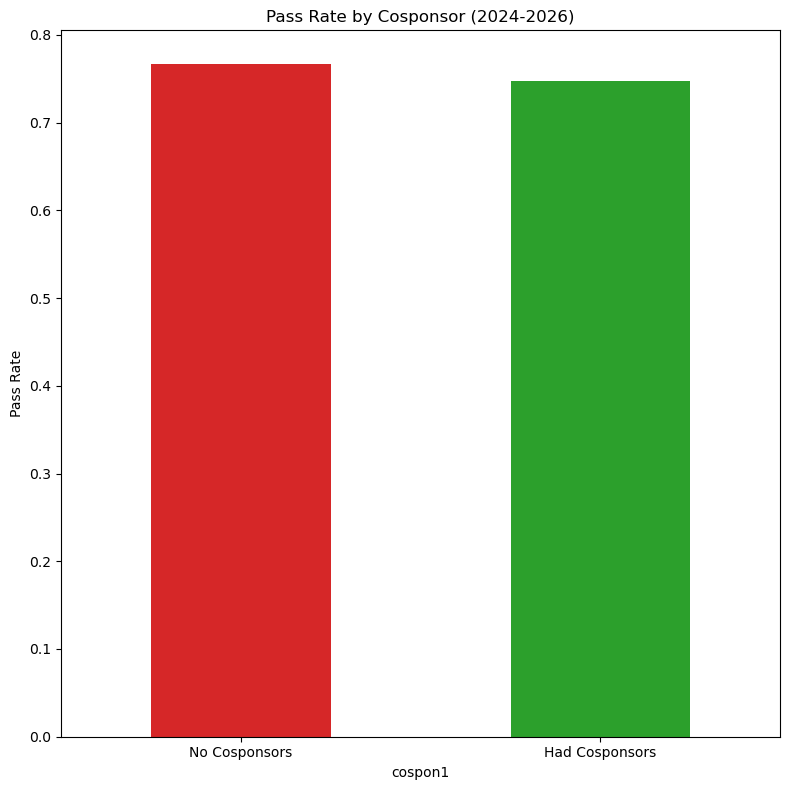

In [31]:
# cosponsor special

fig, axs = plt.subplots(1,1, figsize=(8,8))

# consponsor status
mask = df_bills['session_year'] >= 2023
ax=axs
df_bills[mask].groupby('cospon1')['passed'].mean().plot(kind='bar', ax=ax, color = [tr, tg])
ax.set_title('Pass Rate by Cosponsor (2024-2026)')
ax.set_xticklabels(['No Cosponsors', 'Had Cosponsors'], rotation=0)
ax.set_ylabel('Pass Rate')

plt.tight_layout()
plt.show()